# ViZDoom PPO: OOD generalization analysis

This notebook discovers versioned `test.py` reports, selects the largest completed run, and compares every OOD condition with the **same-seed** in-distribution control. It does not pool reruns, because repeated runs may reuse identical seeds.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
RESULTS_ROOT = Path('results/ood')
reports = []
for path in sorted(RESULTS_ROOT.glob('*/report.json')):
    report = json.loads(path.read_text(encoding='utf-8'))
    reports.append((path, report))

if not reports:
    raise FileNotFoundError('No reports found. Run: python test.py')

inventory = pd.DataFrame([{
    'run': path.parent.name,
    'episodes_per_condition': report['config']['episodes_per_condition'],
    'device': report.get('metadata', {}).get('model_device', 'not recorded'),
    'created_utc': report.get('metadata', {}).get('created_utc', path.parent.name),
} for path, report in reports]).sort_values(['episodes_per_condition', 'created_utc'])
inventory

,run,episodes_per_condition,device,created_utc
0,20260930T195828_279659Z,2,not recorded,2026-09-30T19:58:31.070473+00:00
1,20260930T195940_698289Z,2,cuda:0,2026-09-30T19:59:44.400725+00:00
2,20260930T195946_759692Z,2,cuda:1,2026-09-30T19:59:50.524599+00:00
3,20260930T200047_151198Z,20,cuda:1,2026-09-30T20:01:05.141009+00:00
4,20260930T201009_099888Z,100,cuda:1,2026-09-30T20:11:16.797023+00:00


In [2]:
# Prefer the newest run among those with the largest episode count.
selected_path, selected = max(
    reports,
    key=lambda item: (item[1]['config']['episodes_per_condition'], item[0].parent.name),
)
episodes = pd.DataFrame(selected['episodes'])
condition_order = [item['name'] for item in selected['config']['conditions']]
episodes['condition'] = pd.Categorical(episodes['condition'], condition_order, ordered=True)
print(f'Selected: {selected_path.parent}')
print(f"Episodes per condition: {selected['config']['episodes_per_condition']}")
episodes.head()

Selected: results\ood\20260930T201009_099888Z
Episodes per condition: 100


,condition,episode,seed,reward,raw_reward,decisions,positive_reward
0,id_control,1,7000,0.46,46.0,12,True
1,id_control,2,7001,0.76,76.0,5,True
2,id_control,3,7002,-3.10,-310.0,75,False
3,id_control,4,7003,0.95,95.0,2,True
4,id_control,5,7004,0.76,76.0,5,True


In [3]:
def bootstrap_mean_ci(values, iterations=10_000, seed=340):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(iterations, len(values)), replace=True).mean(axis=1)
    return np.quantile(samples, [0.025, 0.975])

summary_rows = []
for condition, frame in episodes.groupby('condition', observed=True):
    low, high = bootstrap_mean_ci(frame['reward'])
    summary_rows.append({
        'condition': str(condition),
        'episodes': len(frame),
        'mean_reward': frame['reward'].mean(),
        'ci_low': low,
        'ci_high': high,
        'median_reward': frame['reward'].median(),
        'success_rate': frame['positive_reward'].mean(),
        'mean_decisions': frame['decisions'].mean(),
    })
summary = pd.DataFrame(summary_rows).set_index('condition').loc[condition_order].reset_index()
summary.style.format({
    'mean_reward': '{:.3f}', 'ci_low': '{:.3f}', 'ci_high': '{:.3f}',
    'median_reward': '{:.3f}', 'success_rate': '{:.1%}', 'mean_decisions': '{:.1f}',
})

,condition,episodes,mean_reward,ci_low,ci_high,median_reward,success_rate,mean_decisions
0,id_control,100,-0.732,-1.094,-0.371,0.460,63.0%,32.4
1,flicker_25,100,-0.795,-1.155,-0.432,0.460,61.0%,33.8
2,dark_55,100,-0.778,-1.139,-0.422,0.380,62.0%,33.2
3,noise_25,100,-0.798,-1.175,-0.430,0.455,63.0%,32.6
4,frame_skip_2,100,-0.655,-1.007,-0.303,0.510,65.0%,61.5
5,combined_flicker_dark,100,-0.867,-1.227,-0.505,0.460,59.0%,35.0


In [4]:
# Matched-seed comparison removes variation caused by different Doom episodes.
reward_matrix = episodes.pivot(index='seed', columns='condition', values='reward')
reward_matrix = reward_matrix[condition_order]
deltas = reward_matrix.subtract(reward_matrix['id_control'], axis=0)
paired = pd.DataFrame({
    'mean_delta_vs_control': deltas.mean(),
    'worse_seeds': (deltas < -1e-9).sum(),
    'equal_seeds': (deltas.abs() <= 1e-9).sum(),
    'better_seeds': (deltas > 1e-9).sum(),
}).drop(index='id_control')
paired.style.format({'mean_delta_vs_control': '{:+.4f}'})

,mean_delta_vs_control,worse_seeds,equal_seeds,better_seeds
condition,,,,
flicker_25,-0.0626,22,54,24
dark_55,-0.0455,8,90,2
noise_25,-0.0663,49,38,13
frame_skip_2,+0.0770,11,74,15
combined_flicker_dark,-0.1353,23,51,26


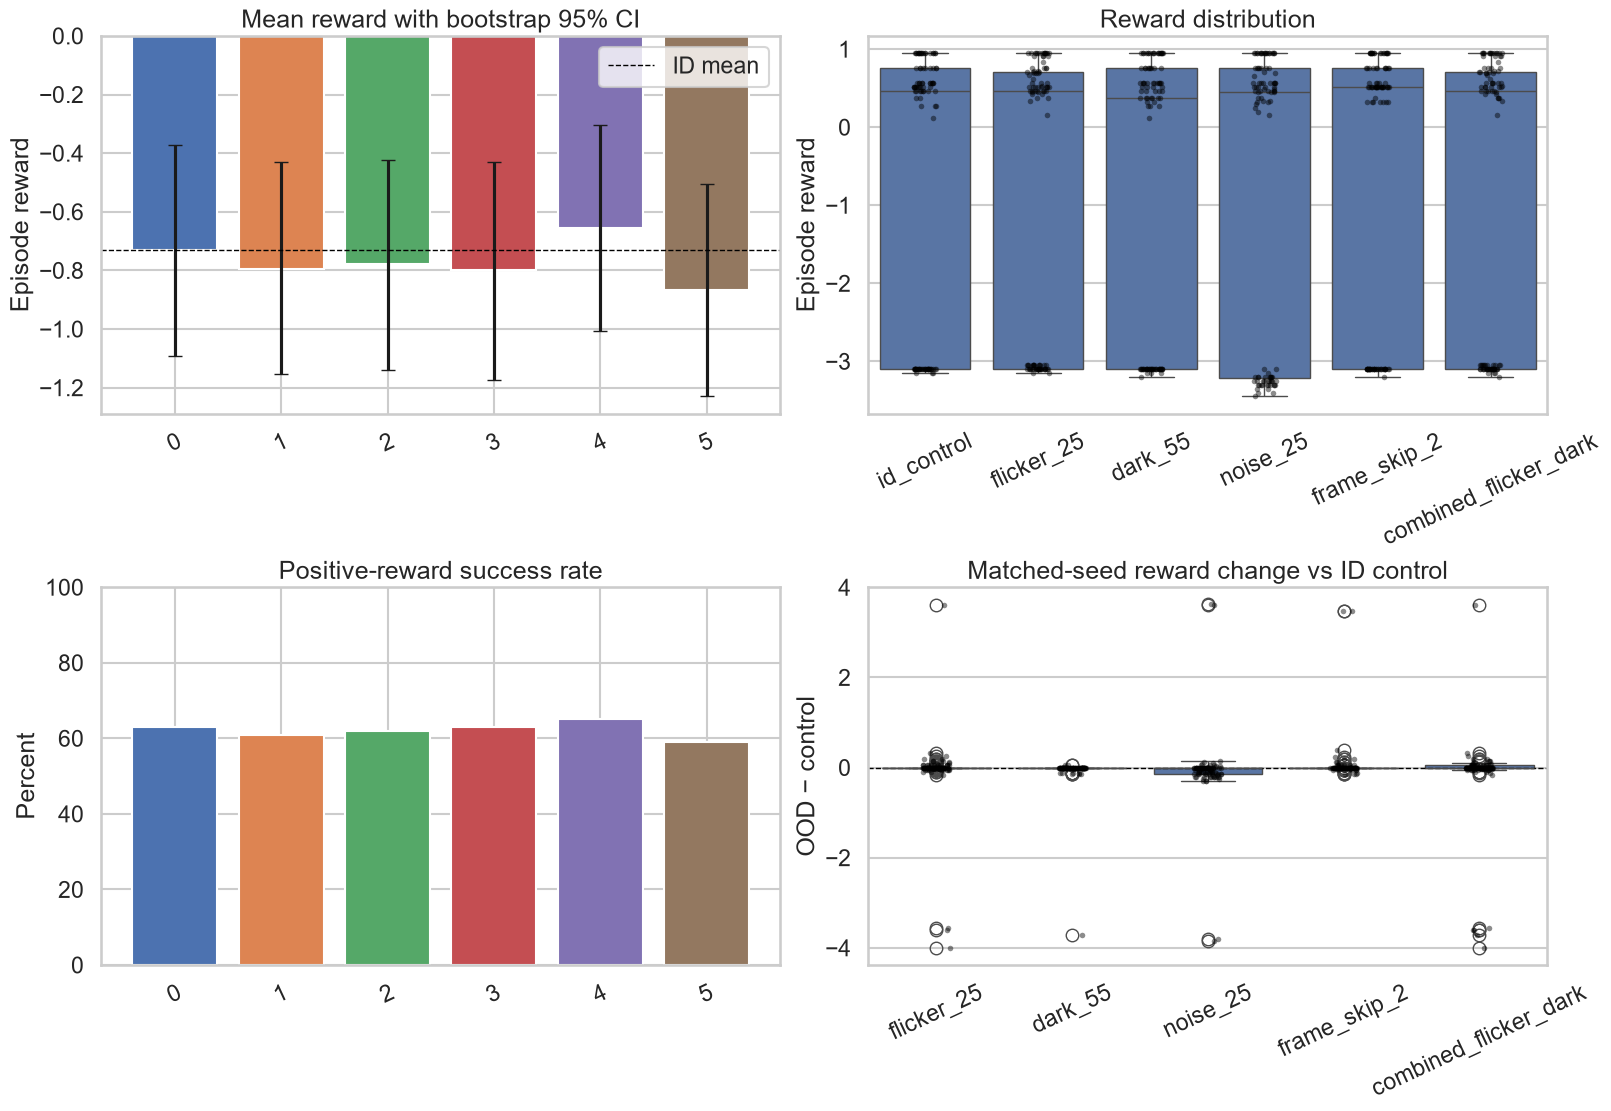

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
x = np.arange(len(summary))
means = summary['mean_reward'].to_numpy()
errors = np.vstack([means - summary['ci_low'], summary['ci_high'] - means])
axes[0, 0].bar(x, means, yerr=errors, capsize=5, color=sns.color_palette('deep', len(x)))
axes[0, 0].axhline(means[0], color='black', linestyle='--', linewidth=1, label='ID mean')
axes[0, 0].set(title='Mean reward with bootstrap 95% CI', ylabel='Episode reward')
axes[0, 0].legend()

sns.boxplot(data=episodes, x='condition', y='reward', order=condition_order, ax=axes[0, 1])
sns.stripplot(data=episodes, x='condition', y='reward', order=condition_order, ax=axes[0, 1], color='black', alpha=.45, size=4)
axes[0, 1].set(title='Reward distribution', xlabel='', ylabel='Episode reward')

axes[1, 0].bar(x, summary['success_rate'] * 100, color=sns.color_palette('deep', len(x)))
axes[1, 0].set(title='Positive-reward success rate', ylabel='Percent', ylim=(0, 100))

delta_long = deltas.drop(columns='id_control').reset_index().melt(id_vars='seed', var_name='condition', value_name='reward_delta')
sns.boxplot(data=delta_long, x='condition', y='reward_delta', order=condition_order[1:], ax=axes[1, 1])
sns.stripplot(data=delta_long, x='condition', y='reward_delta', order=condition_order[1:], ax=axes[1, 1], color='black', alpha=.45, size=4)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set(title='Matched-seed reward change vs ID control', xlabel='', ylabel='OOD − control')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25)
plt.show()

## Interpretation guide

A convincing generalization problem would show a meaningful reward or success-rate drop across many matched seeds, ideally with uncertainty intervals separated from the control. Small reward changes with the same success rate are weak evidence. Also remember that ViZDoom Basic is extremely short: a ceiling effect can hide differences that may become visible in Deadly Corridor or a purpose-built partially observable scenario.